# KerasClassification

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('C:/Users/Ayushi/Desktop/Udemy/Python DS/TensorFlow_FILES/DATA/cancer_classification.csv')

In [4]:
df.isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          False         False           False      False            False   
1          False         False           False      False            False   
2          False         False           False      False            False   
3          False         False           False      False            False   
4          False         False           False      False            False   
..           ...           ...             ...        ...              ...   
564        False         False           False      False            False   
565        False         False           False      False            False   
566        False         False           False      False            False   
567        False         False           False      False            False   
568        False         False           False      False            False   

 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [7]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


<Axes: xlabel='benign_0__mal_1', ylabel='count'>

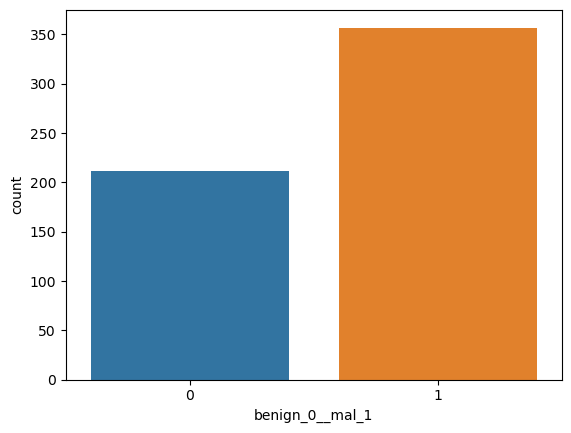

In [8]:
#plt.figure(figsize = (10,6) )
sns.countplot(x ='benign_0__mal_1' , data =df )

<Axes: >

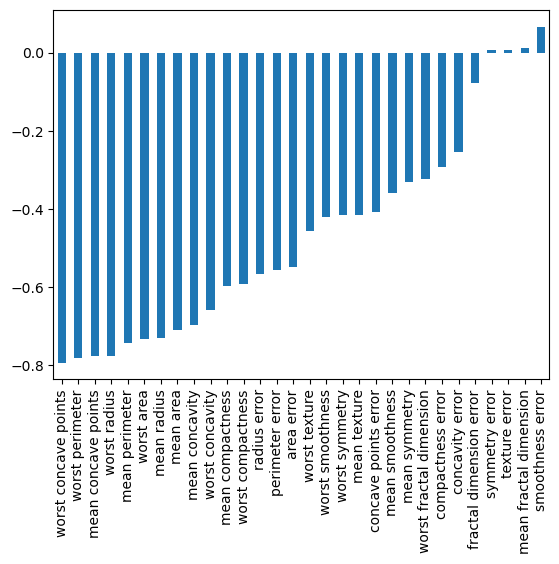

In [18]:
df.corr()['benign_0__mal_1'][:-1].sort_values().plot(kind = 'bar')

<Axes: >

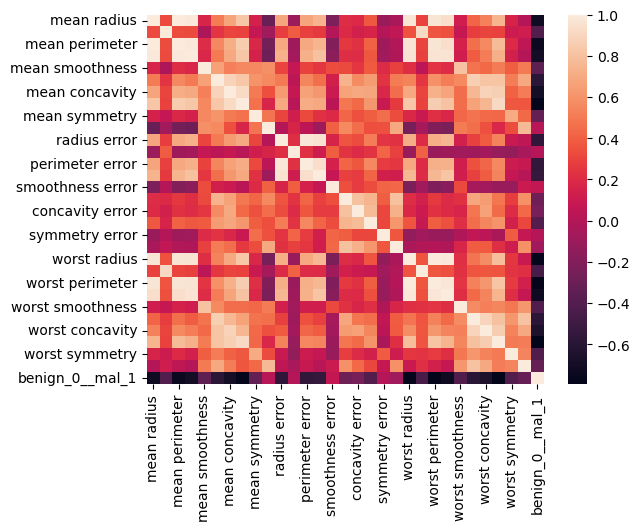

In [19]:
sns.heatmap(df.corr())

In [20]:
X = df.drop('benign_0__mal_1' ,axis =1).values
y = df['benign_0__mal_1'].values

In [22]:
from sklearn.model_selection import train_test_split
X_test , X_train , y_test , y_train   = train_test_split (X , y ,test_size = 0.25 , random_state =101 )

In [23]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

In [27]:
X_train.shape

(143, 30)

In [28]:
model = Sequential()
model.add(Dense(30 , activation ='relu'))
model.add(Dense(15 , activation ='relu'))
#binary classification
model.add(Dense(1, activation ='sigmoid'))
model.compile(optimizer='adam' , loss ='binary_crossentropy')

In [29]:
model.fit(x = X_train , y = y_train , 
          validation_data = (X_test,y_test) ,  epochs =600) #batch_size =128 ,

Epoch 1/600
5/5 [==============================] - 1s 75ms/step - loss: 0.7132 - val_loss: 0.7057
Epoch 2/600
5/5 [==============================] - 0s 15ms/step - loss: 0.6942 - val_loss: 0.6889
Epoch 3/600
5/5 [==============================] - 0s 21ms/step - loss: 0.6767 - val_loss: 0.6727
Epoch 4/600
5/5 [==============================] - 0s 21ms/step - loss: 0.6602 - val_loss: 0.6576
Epoch 5/600
5/5 [==============================] - 0s 12ms/step - loss: 0.6472 - val_loss: 0.6435
Epoch 6/600
5/5 [==============================] - 0s 16ms/step - loss: 0.6295 - val_loss: 0.6294
Epoch 7/600
5/5 [==============================] - 0s 24ms/step - loss: 0.6151 - val_loss: 0.6143
Epoch 8/600
5/5 [==============================] - 0s 21ms/step - loss: 0.6006 - val_loss: 0.5996
Epoch 9/600
5/5 [==============================] - 0s 26ms/step - loss: 0.5849 - val_loss: 0.5838
Epoch 10/600
5/5 [==============================] - 0s 23ms/step - loss: 0.5685 - val_loss: 0.5676
Epoch 11/600
5/5 [=

Epoch 84/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0867 - val_loss: 0.1509
Epoch 85/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0858 - val_loss: 0.1507
Epoch 86/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0838 - val_loss: 0.1523
Epoch 87/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0823 - val_loss: 0.1536
Epoch 88/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0813 - val_loss: 0.1549
Epoch 89/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0812 - val_loss: 0.1553
Epoch 90/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0791 - val_loss: 0.1489
Epoch 91/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0771 - val_loss: 0.1437
Epoch 92/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0779 - val_loss: 0.1428
Epoch 93/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0756 - val_loss: 0.1457
Epoch 94/6

5/5 [==============================] - 0s 11ms/step - loss: 0.0330 - val_loss: 0.1109
Epoch 167/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0331 - val_loss: 0.1116
Epoch 168/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0333 - val_loss: 0.1142
Epoch 169/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0332 - val_loss: 0.1074
Epoch 170/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0321 - val_loss: 0.1098
Epoch 171/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0320 - val_loss: 0.1080
Epoch 172/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0315 - val_loss: 0.1091
Epoch 173/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0316 - val_loss: 0.1147
Epoch 174/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0315 - val_loss: 0.1108
Epoch 175/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0313 - val_loss: 0.1012
Epoch 176/600


5/5 [==============================] - 0s 12ms/step - loss: 0.0184 - val_loss: 0.1033
Epoch 249/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0177 - val_loss: 0.1012
Epoch 250/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0173 - val_loss: 0.1008
Epoch 251/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0171 - val_loss: 0.0998
Epoch 252/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0170 - val_loss: 0.0996
Epoch 253/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0171 - val_loss: 0.1004
Epoch 254/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0176 - val_loss: 0.0936
Epoch 255/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0171 - val_loss: 0.0978
Epoch 256/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0174 - val_loss: 0.1046
Epoch 257/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0168 - val_loss: 0.1001
Epoch 258/600


5/5 [==============================] - 0s 13ms/step - loss: 0.0105 - val_loss: 0.1047
Epoch 331/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0102 - val_loss: 0.1018
Epoch 332/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0102 - val_loss: 0.1034
Epoch 333/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0105 - val_loss: 0.1111
Epoch 334/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0101 - val_loss: 0.1025
Epoch 335/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0100 - val_loss: 0.1024
Epoch 336/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0099 - val_loss: 0.1053
Epoch 337/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0097 - val_loss: 0.1067
Epoch 338/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0096 - val_loss: 0.1061
Epoch 339/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0097 - val_loss: 0.1065
Epoch 340/600


5/5 [==============================] - 0s 20ms/step - loss: 0.0060 - val_loss: 0.1193
Epoch 413/600
5/5 [==============================] - 0s 28ms/step - loss: 0.0058 - val_loss: 0.1193
Epoch 414/600
5/5 [==============================] - 0s 18ms/step - loss: 0.0058 - val_loss: 0.1200
Epoch 415/600
5/5 [==============================] - 0s 19ms/step - loss: 0.0057 - val_loss: 0.1177
Epoch 416/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0056 - val_loss: 0.1139
Epoch 417/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0058 - val_loss: 0.1126
Epoch 418/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0058 - val_loss: 0.1212
Epoch 419/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0055 - val_loss: 0.1183
Epoch 420/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0055 - val_loss: 0.1167
Epoch 421/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0055 - val_loss: 0.1183
Epoch 422/600


5/5 [==============================] - 0s 13ms/step - loss: 0.0035 - val_loss: 0.1232
Epoch 495/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0034 - val_loss: 0.1242
Epoch 496/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0033 - val_loss: 0.1309
Epoch 497/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0033 - val_loss: 0.1332
Epoch 498/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0033 - val_loss: 0.1320
Epoch 499/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0032 - val_loss: 0.1330
Epoch 500/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0033 - val_loss: 0.1383
Epoch 501/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0032 - val_loss: 0.1315
Epoch 502/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0031 - val_loss: 0.1282
Epoch 503/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0031 - val_loss: 0.1297
Epoch 504/600


5/5 [==============================] - 0s 13ms/step - loss: 0.0020 - val_loss: 0.1438
Epoch 577/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0019 - val_loss: 0.1371
Epoch 578/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0021 - val_loss: 0.1386
Epoch 579/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0020 - val_loss: 0.1378
Epoch 580/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0021 - val_loss: 0.1470
Epoch 581/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0019 - val_loss: 0.1402
Epoch 582/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0020 - val_loss: 0.1388
Epoch 583/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0020 - val_loss: 0.1444
Epoch 584/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0019 - val_loss: 0.1448
Epoch 585/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0019 - val_loss: 0.1444
Epoch 586/600


<Axes: >

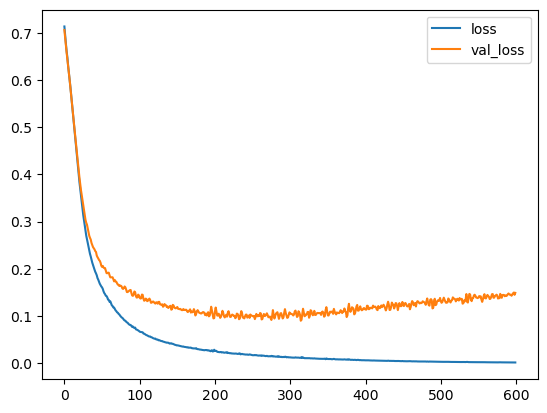

In [30]:
losses = pd.DataFrame(model.history.history)
losses.plot()

In [48]:
model = Sequential()
model.add(Dense(30 , activation ='relu'))
model.add(Dense(15 , activation ='relu'))
#binary classification
model.add(Dense(1, activation ='sigmoid'))
model.compile(optimizer='adam' , loss ='binary_crossentropy')

In [49]:
from tensorflow.keras.callbacks import EarlyStopping

In [50]:
early_stop  =  EarlyStopping(monitor='val_loss' , mode ='min' , verbose= 1 , patience =25)

In [51]:
model.fit(x = X_train , y = y_train , 
          validation_data = (X_test,y_test) ,  epochs =600 , callbacks=  [early_stop]) #batch_size =128 ,

Epoch 1/600
5/5 [==============================] - 1s 39ms/step - loss: 0.7019 - val_loss: 0.6975
Epoch 2/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6902 - val_loss: 0.6869
Epoch 3/600
5/5 [==============================] - 0s 12ms/step - loss: 0.6789 - val_loss: 0.6770
Epoch 4/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6688 - val_loss: 0.6660
Epoch 5/600
5/5 [==============================] - 0s 13ms/step - loss: 0.6577 - val_loss: 0.6544
Epoch 6/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6463 - val_loss: 0.6418
Epoch 7/600
5/5 [==============================] - 0s 15ms/step - loss: 0.6338 - val_loss: 0.6283
Epoch 8/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6199 - val_loss: 0.6133
Epoch 9/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6041 - val_loss: 0.5974
Epoch 10/600
5/5 [==============================] - 0s 14ms/step - loss: 0.5879 - val_loss: 0.5804
Epoch 11/600
5/5 [=

Epoch 84/600
5/5 [==============================] - 0s 16ms/step - loss: 0.0804 - val_loss: 0.1588
Epoch 85/600
5/5 [==============================] - 0s 17ms/step - loss: 0.0795 - val_loss: 0.1613
Epoch 86/600
5/5 [==============================] - 0s 21ms/step - loss: 0.0773 - val_loss: 0.1542
Epoch 87/600
5/5 [==============================] - 0s 19ms/step - loss: 0.0756 - val_loss: 0.1512
Epoch 88/600
5/5 [==============================] - 0s 20ms/step - loss: 0.0752 - val_loss: 0.1502
Epoch 89/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0741 - val_loss: 0.1486
Epoch 90/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0731 - val_loss: 0.1501
Epoch 91/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0719 - val_loss: 0.1519
Epoch 92/600
5/5 [==============================] - 0s 10ms/step - loss: 0.0709 - val_loss: 0.1519
Epoch 93/600
5/5 [==============================] - 0s 15ms/step - loss: 0.0700 - val_loss: 0.1511
Epoch 94/6

5/5 [==============================] - 0s 13ms/step - loss: 0.0314 - val_loss: 0.1187
Epoch 167/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0315 - val_loss: 0.1177
Epoch 168/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0319 - val_loss: 0.1246
Epoch 169/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0309 - val_loss: 0.1229
Epoch 170/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0306 - val_loss: 0.1207
Epoch 171/600
5/5 [==============================] - 0s 13ms/step - loss: 0.0301 - val_loss: 0.1169
Epoch 172/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0307 - val_loss: 0.1149
Epoch 173/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0323 - val_loss: 0.1258
Epoch 174/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0294 - val_loss: 0.1164
Epoch 175/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0292 - val_loss: 0.1117
Epoch 176/600


<Axes: >

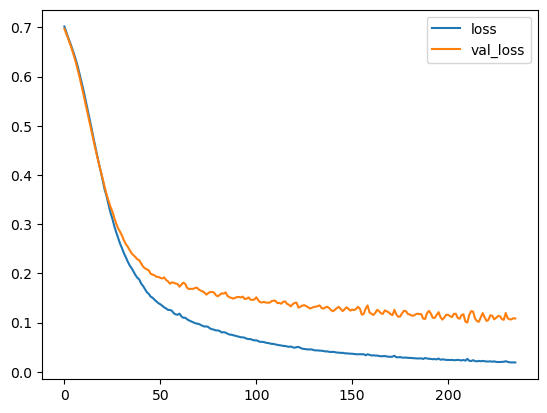

In [52]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [56]:
model = Sequential()

model.add(Dense(30 , activation ='relu'))
model.add(Dropout(0.5))

model.add(Dense(15 , activation ='relu'))
model.add(Dropout(0.5))


#binary classification
model.add(Dense(1, activation ='sigmoid'))
model.compile(optimizer='adam' , loss ='binary_crossentropy')

In [57]:
model.fit(x = X_train , y = y_train , 
          validation_data = (X_test,y_test) ,  epochs =600 , callbacks=  [early_stop]) #batch_size =128 ,

Epoch 1/600
5/5 [==============================] - 1s 52ms/step - loss: 0.7174 - val_loss: 0.7028
Epoch 2/600
5/5 [==============================] - 0s 15ms/step - loss: 0.7436 - val_loss: 0.6894
Epoch 3/600
5/5 [==============================] - 0s 16ms/step - loss: 0.7035 - val_loss: 0.6805
Epoch 4/600
5/5 [==============================] - 0s 17ms/step - loss: 0.6841 - val_loss: 0.6744
Epoch 5/600
5/5 [==============================] - 0s 15ms/step - loss: 0.6744 - val_loss: 0.6701
Epoch 6/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6661 - val_loss: 0.6657
Epoch 7/600
5/5 [==============================] - 0s 16ms/step - loss: 0.6871 - val_loss: 0.6608
Epoch 8/600
5/5 [==============================] - 0s 15ms/step - loss: 0.6830 - val_loss: 0.6552
Epoch 9/600
5/5 [==============================] - 0s 15ms/step - loss: 0.6560 - val_loss: 0.6480
Epoch 10/600
5/5 [==============================] - 0s 14ms/step - loss: 0.6638 - val_loss: 0.6405
Epoch 11/600
5/5 [=

Epoch 84/600
5/5 [==============================] - 0s 14ms/step - loss: 0.2483 - val_loss: 0.2258
Epoch 85/600
5/5 [==============================] - 0s 11ms/step - loss: 0.2285 - val_loss: 0.2246
Epoch 86/600
5/5 [==============================] - 0s 11ms/step - loss: 0.2399 - val_loss: 0.2277
Epoch 87/600
5/5 [==============================] - 0s 9ms/step - loss: 0.2542 - val_loss: 0.2304
Epoch 88/600
5/5 [==============================] - 0s 10ms/step - loss: 0.2175 - val_loss: 0.2287
Epoch 89/600
5/5 [==============================] - 0s 14ms/step - loss: 0.2646 - val_loss: 0.2239
Epoch 90/600
5/5 [==============================] - 0s 15ms/step - loss: 0.2275 - val_loss: 0.2199
Epoch 91/600
5/5 [==============================] - 0s 13ms/step - loss: 0.2362 - val_loss: 0.2174
Epoch 92/600
5/5 [==============================] - 0s 12ms/step - loss: 0.2546 - val_loss: 0.2171
Epoch 93/600
5/5 [==============================] - 0s 12ms/step - loss: 0.2402 - val_loss: 0.2169
Epoch 94/60

5/5 [==============================] - 0s 17ms/step - loss: 0.1450 - val_loss: 0.1667
Epoch 167/600
5/5 [==============================] - 0s 14ms/step - loss: 0.1461 - val_loss: 0.1660
Epoch 168/600
5/5 [==============================] - 0s 12ms/step - loss: 0.1535 - val_loss: 0.1697
Epoch 169/600
5/5 [==============================] - 0s 11ms/step - loss: 0.1380 - val_loss: 0.1713
Epoch 170/600
5/5 [==============================] - 0s 12ms/step - loss: 0.1501 - val_loss: 0.1718
Epoch 171/600
5/5 [==============================] - 0s 10ms/step - loss: 0.1129 - val_loss: 0.1653
Epoch 172/600
5/5 [==============================] - 0s 9ms/step - loss: 0.1286 - val_loss: 0.1635
Epoch 173/600
5/5 [==============================] - 0s 9ms/step - loss: 0.1125 - val_loss: 0.1624
Epoch 174/600
5/5 [==============================] - 0s 12ms/step - loss: 0.1471 - val_loss: 0.1619
Epoch 175/600
5/5 [==============================] - 0s 14ms/step - loss: 0.1033 - val_loss: 0.1648
Epoch 176/600
5/

5/5 [==============================] - 0s 16ms/step - loss: 0.1151 - val_loss: 0.1431
Epoch 249/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0954 - val_loss: 0.1511
Epoch 250/600
5/5 [==============================] - 0s 14ms/step - loss: 0.0829 - val_loss: 0.1583
Epoch 251/600
5/5 [==============================] - 0s 11ms/step - loss: 0.1155 - val_loss: 0.1573
Epoch 252/600
5/5 [==============================] - 0s 9ms/step - loss: 0.0872 - val_loss: 0.1434
Epoch 253/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0895 - val_loss: 0.1378
Epoch 254/600
5/5 [==============================] - 0s 12ms/step - loss: 0.1073 - val_loss: 0.1374
Epoch 255/600
5/5 [==============================] - 0s 11ms/step - loss: 0.0960 - val_loss: 0.1436
Epoch 256/600
5/5 [==============================] - 0s 12ms/step - loss: 0.0971 - val_loss: 0.1506
Epoch 257/600
5/5 [==============================] - 0s 9ms/step - loss: 0.0709 - val_loss: 0.1524
Epoch 258/600
5/

<Axes: >

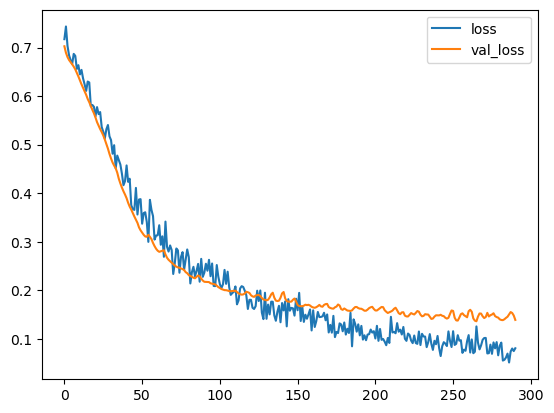

In [58]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [66]:
predictions = (model.predict(X_test) > 0.5).astype(int)

14/14 [==============================] - 0s 3ms/step


In [69]:
from sklearn.metrics import classification_report , confusion_matrix

In [70]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       157
           1       0.95      0.97      0.96       269

    accuracy                           0.95       426
   macro avg       0.95      0.94      0.94       426
weighted avg       0.95      0.95      0.95       426



In [72]:
print(confusion_matrix(y_test, predictions))

[[144  13]
 [  9 260]]
